In [8]:
from data_processing import load_data
from backtest import run_backtest
from mvo import *
from run_portfolio import compute_metrics

In [9]:
mu_baseline, mu_regime, daily_log_returns, cumulative_returns, rebalancing_datess = load_data("data/binance_data_raw.csv","outputs_draft/all_forecasts.csv")

In [10]:
# === make changes to data
import pandas as pd
import numpy as np

In [11]:
# === modify load_data
all_forecasts = pd.read_csv("outputs_draft/all_forecasts.csv", parse_dates=True)
df_hist = pd.read_csv("data/binance_data_raw.csv", parse_dates=True)

In [12]:
df_hist = df_hist[["date", "crypto", "log_return"]]

In [13]:
mu_baseline = all_forecasts[all_forecasts["model_type"] == "baseline"].pivot(index="date", columns="crypto", values="y_pred")
mu_regime   = all_forecasts[all_forecasts["model_type"] == "regime"].pivot(index="date", columns="crypto", values="y_pred")
daily_log_returns = df_hist.pivot(index="date", columns="crypto", values="log_return")

In [14]:
# compute 7d cumulative return
cumulative_returns = daily_log_returns.rolling(window=7).sum()
cumulative_returns

crypto,ADAUSDT,BCHUSDT,BNBUSDT,BTCUSDT,ETHUSDT,LINKUSDT,LTCUSDT,XRPUSDT
date,,,,,,,,
2020-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2025-12-20,-0.095798,0.020820,-0.048725,-0.021043,-0.044885,-0.089794,-0.045579,-0.045101
2025-12-21,-0.078992,0.057089,-0.021465,0.005505,-0.020273,-0.065342,-0.027867,-0.028766
2025-12-22,-0.045049,0.096480,0.000070,0.025008,0.014944,-0.021236,-0.005952,0.003261


In [15]:
# def load_data(hist_data_fp, forecast_fp):
#     all_forecasts = pd.read_csv(forecast_fp, parse_dates=True)

#     mu_baseline = all_forecasts[all_forecasts["model_type"] == "baseline"].pivot(index="date", columns="crypto", values="y_pred")
#     mu_regime   = all_forecasts[all_forecasts["model_type"] == "regime"].pivot(index="date", columns="crypto", values="y_pred")

#     df_hist = pd.read_csv(hist_data_fp, parse_dates=True)
#     df_hist = df_hist[["date", "crypto", "log_return"]] # daily log returns

#     # align dates and cryptos between forecasts and historical returns
#     start_date = max(mu_baseline.index.min(), mu_regime.index.min(), df_hist["date"].min())
#     end_date = min(mu_baseline.index.max(), mu_regime.index.max(), df_hist["date"].max())
#     df_hist = df_hist[(df_hist["date"] >= start_date) & (df_hist["date"] <= end_date)]
#     daily_log_returns = df_hist.pivot(index="date", columns="crypto", values="log_return")
#     cumulative_returns = daily_log_returns.rolling(window=7).sum() # compute backward looking 7d cumulative returns 
    
#     # keep only test dates for evaluation
#     test_dates = sorted(all_forecasts.loc[all_forecasts["split"] == "test", "date"].unique())
#     # take every 7th date to match weekly rebalancing
#     rebalancing_dates = test_dates[::7]
#     rebalancing_dates = pd.to_datetime(rebalancing_dates)
#     return mu_baseline, mu_regime, daily_log_returns, cumulative_returns, rebalancing_dates

In [16]:
mu_baseline, mu_regime, daily_log_returns, cumulative_returns, rebalancing_dates = load_data("data/binance_data_raw.csv", "outputs_draft/all_forecasts.csv")

In [17]:
print(f"===== Checking dates alignment =====")
print("Mu baseline dates:", mu_baseline.index.min(), "to", mu_baseline.index.max())
print("Mu regime dates:", mu_regime.index.min(), "to", mu_regime.index.max())
print("Daily log returns dates:", daily_log_returns.index.min(), "to", daily_log_returns.index.max())
print("Cumulative returns dates:", cumulative_returns.index.min(), "to", cumulative_returns.index.max())

===== Checking dates alignment =====
Mu baseline dates: 2024-01-01 to 2025-12-24
Mu regime dates: 2024-01-01 to 2025-12-24
Daily log returns dates: 2024-01-01 to 2025-12-24
Cumulative returns dates: 2024-01-01 to 2025-12-24


In [18]:
# # edit run_backtest
# mu = mu_baseline  # or mu_regime
# # real_returns = daily_log_returns
# # eval_dates = rebalancing_dates
# window = 4  # use past 4 weeks (28 days) of data for covariance estimation
# lamda = 0.1  # risk aversion parameter

# portfolio_returns = []
# weights_history = []

# dates = mu.index
# assets = mu.columns

In [19]:
rebalancing_dates[0].strftime('%Y-%m-%d')

'2025-01-01'

In [20]:
# for _ in sorted(rebalancing_dates):
# current_date = _.strftime('%Y-%m-%d')
# t_idx = cumulative_returns.index.get_loc(_.strftime('%Y-%m-%d'))
# # print(f"Processing date: {current_date} for ADAUSDT with data: {cumulative_returns["ADAUSDT"].iloc[t_idx]}")
# # compute 7d cumulative return up to current date for covariance estimation
# hist_7d = cumulative_returns.iloc[t_idx - (window-1)*7 : t_idx + 1 : 7]
# cov_t = hist_7d.cov().values
# mu_t = mu.loc[current_date].values # should by 7-day cumulative return forecasts (expected returns for the next 7 days)
# # print(f"Covariance matrix on {current_date}:\n{cov_t}")
# # print(f"mu_t on {current_date}:\n{mu_t}")
# w_t = optimize_portfolio(mu_t, cov_t, lamda=lamda)

# realised_7d = daily_log_returns.iloc[t_idx+1 : t_idx+8].sum(axis=0).values # actual return from holding period (next 7 days)
# portfolio_return = np.dot(w_t, realised_7d)
# portfolio_returns.append(portfolio_return)
# weights_history.append(w_t)

In [22]:
base_ret, base_w = run_backtest(
    mu_baseline,
    daily_log_returns,
    cumulative_returns,
    rebalancing_dates,
    window=20,
    lamda=5.0
)

reg_ret, reg_w = run_backtest(
    mu_regime,
    daily_log_returns,
    cumulative_returns,
    rebalancing_dates,
    window=20,
    lamda=5.0
)

Backtest at 2025-01-01 (index 366)
optimal weights at 2025-01-01: [0.00000000e+00 1.04083409e-16 3.00000000e-01 3.00000000e-01
 1.00000000e-01 0.00000000e+00 3.00000000e-01 0.00000000e+00]
portfolio return at 2025-01-01: -0.015616349909073924
Backtest at 2025-01-08 (index 373)
optimal weights at 2025-01-08: [1.54050501e-16 3.00000000e-01 1.00000000e-01 3.00000000e-01
 2.02642386e-16 3.00000000e-01 2.87096735e-16 2.20632190e-16]
portfolio return at 2025-01-08: 0.06011557774515893
Backtest at 2025-01-15 (index 380)
optimal weights at 2025-01-15: [1.69648145e-16 1.00000000e-01 3.00000000e-01 3.00000000e-01
 1.26541772e-17 3.00000000e-01 1.22084220e-16 0.00000000e+00]
portfolio return at 2025-01-15: 0.036322444009160904
Backtest at 2025-01-22 (index 387)
optimal weights at 2025-01-22: [0.00033762 0.         0.3        0.3        0.09966238 0.
 0.3        0.        ]
portfolio return at 2025-01-22: -0.014750367546978328
Backtest at 2025-01-29 (index 394)
optimal weights at 2025-01-29: [2.22

In [31]:
reg_w

crypto,ADAUSDT,BCHUSDT,BNBUSDT,BTCUSDT,ETHUSDT,LINKUSDT,LTCUSDT,XRPUSDT
2025-01-01,1.858615e-17,5.551115e-17,3.000000e-01,0.300000,1.000000e-01,4.981246e-17,3.000000e-01,8.198476e-17
2025-01-08,1.546945e-17,1.000000e-01,3.000000e-01,0.300000,3.000000e-01,0.000000e+00,0.000000e+00,2.564296e-16
2025-01-15,7.686644e-17,7.375747e-19,3.000000e-01,0.300000,1.000000e-01,3.000000e-01,1.170723e-16,1.917058e-16
2025-01-22,0.000000e+00,0.000000e+00,3.000000e-01,0.300000,1.000000e-01,0.000000e+00,3.000000e-01,0.000000e+00
2025-01-29,9.262809e-17,1.179612e-16,3.000000e-01,0.300000,1.343918e-01,2.656082e-01,3.718524e-17,0.000000e+00
2025-02-05,7.359808e-17,0.000000e+00,3.000000e-01,0.300000,1.000000e-01,4.902664e-17,3.000000e-01,0.000000e+00
2025-02-12,1.197559e-17,0.000000e+00,1.531494e-01,0.300000,3.000000e-01,0.000000e+00,2.468506e-01,2.247788e-16
2025-02-19,0.000000e+00,4.490564e-16,1.000000e-01,0.300000,3.000000e-01,0.000000e+00,3.000000e-01,0.000000e+00
2025-02-26,1.445065e-16,0.000000e+00,1.571752e-01,0.300000,2.796072e-01,0.000000e+00,2.632176e-01,7.764952e-17
2025-03-05,0.000000e+00,0.000000e+00,2.539721e-01,0.221621,2.244068e-01,0.000000e+00,3.000000e-01,1.774012e-16


In [23]:
cum_base = np.exp(base_ret.cumsum())
cum_reg = np.exp(reg_ret.cumsum())

In [24]:
import matplotlib.pyplot as plt

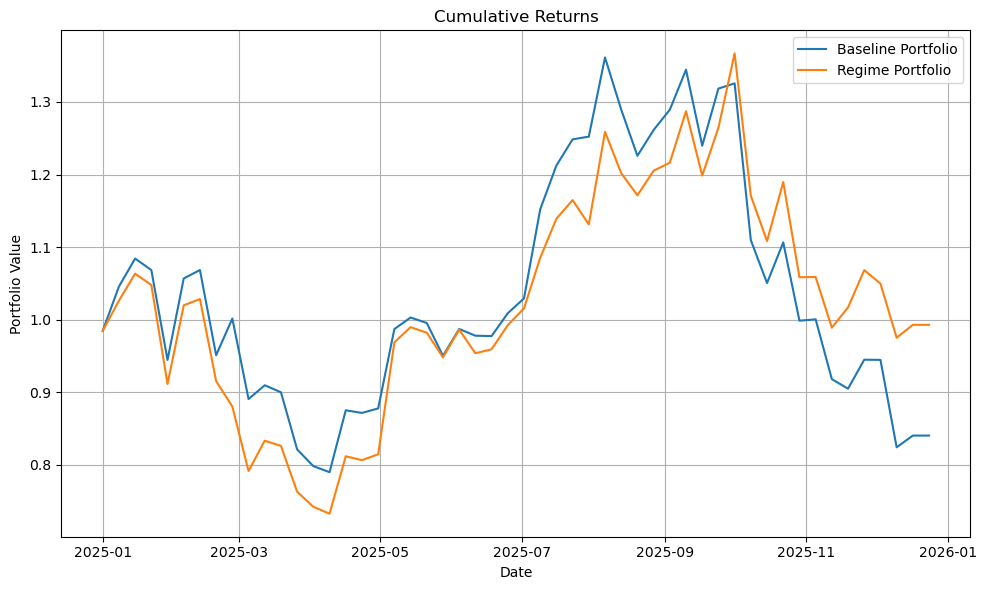

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(pd.to_datetime(cum_base.index), cum_base.values, label="Baseline Portfolio")
plt.plot(pd.to_datetime(cum_reg.index), cum_reg.values, label="Regime Portfolio")
plt.title("Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
### inspect forecasts
import pandas as pd
df_fcst = pd.read_csv("outputs_draft/all_forecasts.csv", parse_dates=True)
df_base = df_fcst[df_fcst["model_type"] == "baseline"]
df_regime = df_fcst[df_fcst["model_type"] == "regime"]
df_test = pd.read_csv("data/test_df.csv", parse_dates=True)
df_test = df_test[["date", "crypto", "target_7d", "regime_label"]]

In [18]:
df_test.columns

Index(['crypto', 'date', 'close', 'log_return', 'open', 'high', 'low',
       'volume', 'target_7d', 'vol_30', 'sma', 'ema', 'momentum', 'cci',
       'regime_label'],
      dtype='object')

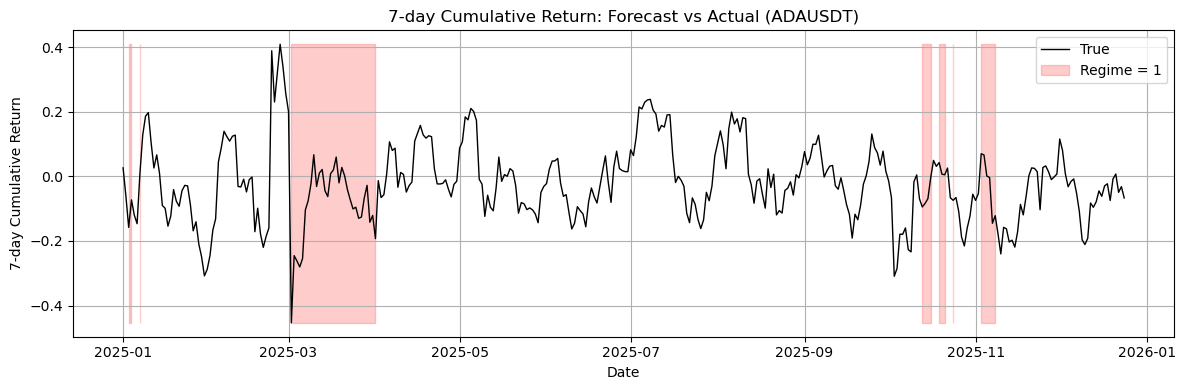

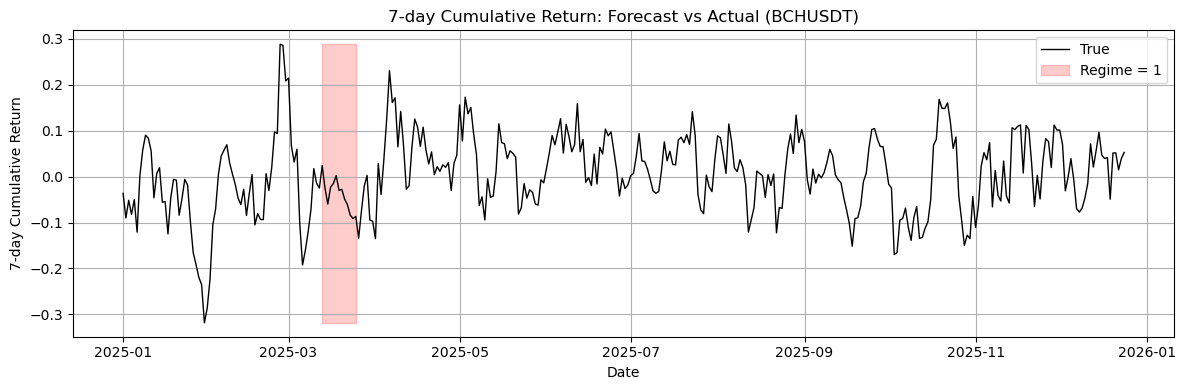

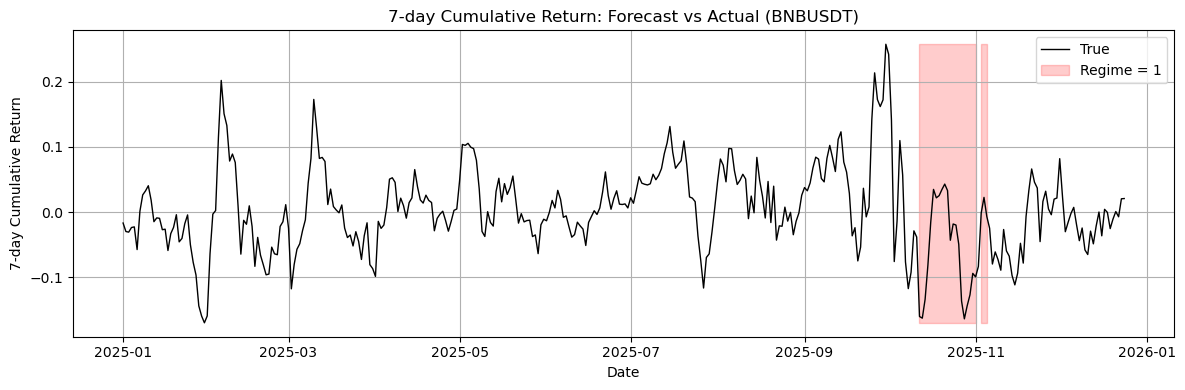

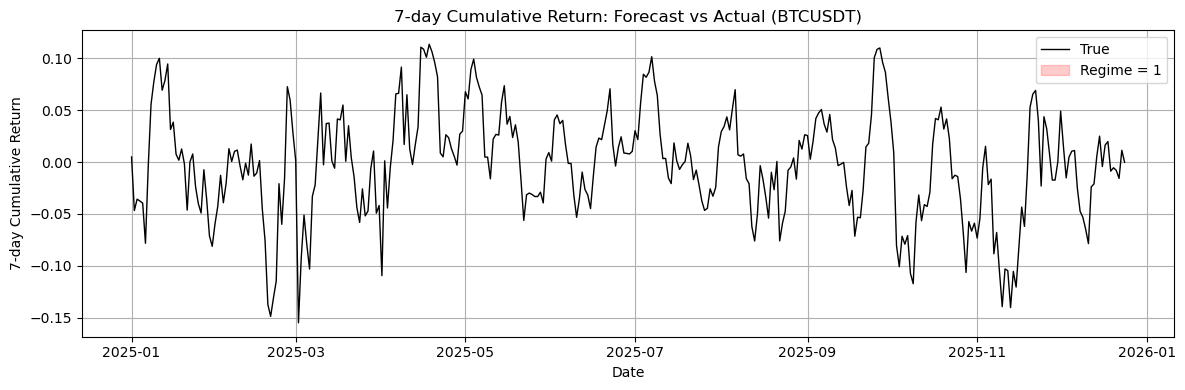

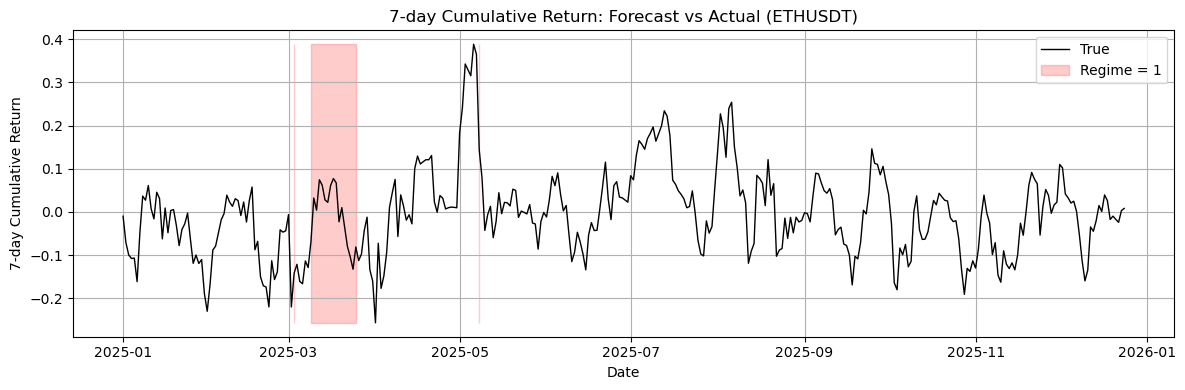

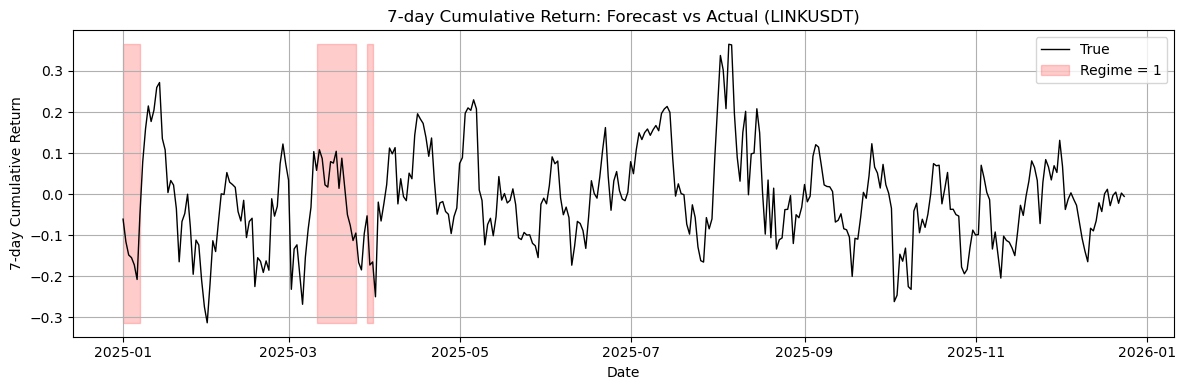

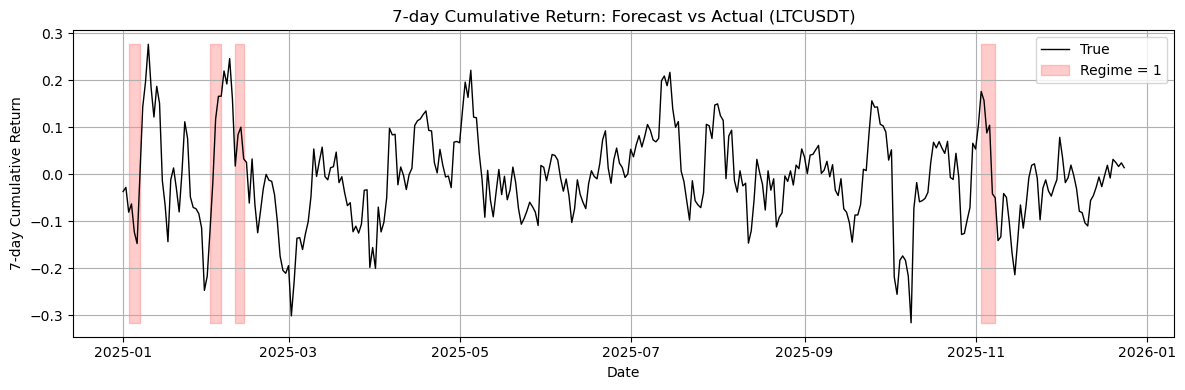

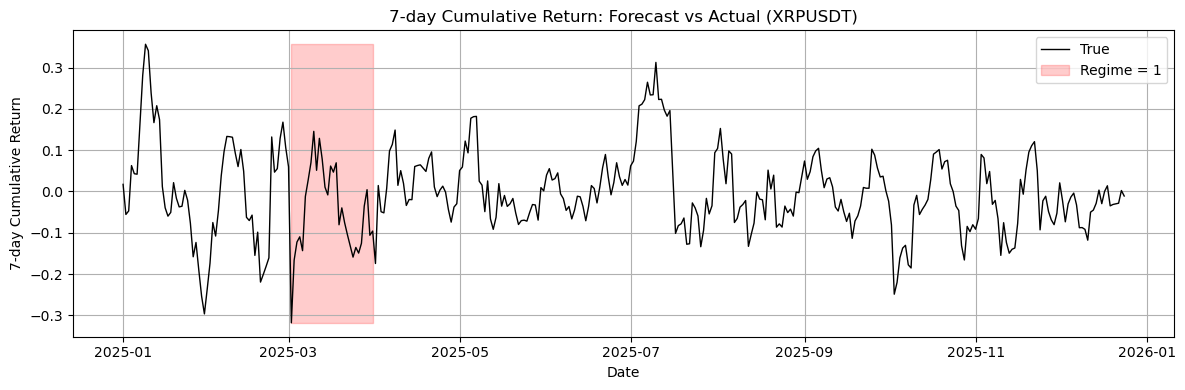

In [ ]:
# === inspect forecasts by asset
# import matplotlib.pyplot as plt
# import pandas as pd

assets = df_fcst["crypto"].unique().tolist()
# # ensure datetime
df_asset_base["date"] = pd.to_datetime(df_asset_base["date"])
df_regime["date"] = pd.to_datetime(df_regime["date"])
df_test["date"] = pd.to_datetime(df_test["date"])

for asset in assets:
    # df_asset_base = df_base[df_base["crypto"] == asset].sort_values("date")
    # df_asset_regime = df_regime[df_regime["crypto"] == asset].sort_values("date")
    df_plot = df_test[df_test["crypto"] == asset].sort_values("date")

    plt.figure(figsize=(12, 4))

    # TRUE values (only need one — same across models ideally)
    # plt.plot(df_asset_base["date"], df_asset_base["y_true"],
    #          color="black", linewidth=1, label="True")
    plt.plot(df_plot["date"], df_plot["target_7d"],
            color="black", linewidth=1, label="True")
    # shading where regime == 1
    plt.fill_between(
        df_plot["date"],
        df_plot["target_7d"].min(),   # lower bound
        df_plot["target_7d"].max(),   # upper bound
        where=(df_plot["regime_label"] == 1),
        color="red",
        alpha=0.2,
        label="Regime = 1"
        )

    # # Baseline predictions
    # plt.plot(df_asset_base["date"], df_asset_base["y_pred"],
    #          color="steelblue", linestyle="--", label="Baseline Forecast")

    # # Regime predictions
    # plt.plot(df_asset_regime["date"], df_asset_regime["y_pred"],
    #          color="tomato", linestyle="--", label="Regime Forecast")

    plt.title(f"7-day Cumulative Return: Forecast vs Actual ({asset})")
    plt.xlabel("Date")
    plt.ylabel("7-day Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
# === inspect difference in performance
from run_portfolio import compute_metrics
from backtest import run_backtest
from data_processing import load_data


In [7]:
OLD_ALL_FCSTS_FP = "outputs_draft/all_forecasts.csv"
HIST_DATA_FP = "data/binance_data_raw.csv"

old_mu_base, old_mu_regime, old_daily_log_returns, old_cumulative_returns, old_rebalancing_dates = load_data(
    HIST_DATA_FP, OLD_ALL_FCSTS_FP
)

# Run backtests
old_base_ret, old_base_w = run_backtest(
    old_mu_base,
    old_daily_log_returns,
    old_cumulative_returns,
    old_rebalancing_dates,
    window=20,
    lamda=5.0
)

old_reg_ret, old_reg_w = run_backtest(
    old_mu_regime,
    old_daily_log_returns,
    old_cumulative_returns,
    old_rebalancing_dates,
    window=20,
    lamda=5.0
)

Backtest at 2025-01-01 (index 366)
optimal weights at 2025-01-01: [0.00000000e+00 1.04083409e-16 3.00000000e-01 3.00000000e-01
 1.00000000e-01 0.00000000e+00 3.00000000e-01 0.00000000e+00]
portfolio return at 2025-01-01: -0.015616349909073924
Backtest at 2025-01-08 (index 373)
optimal weights at 2025-01-08: [1.54050501e-16 3.00000000e-01 1.00000000e-01 3.00000000e-01
 2.02642386e-16 3.00000000e-01 2.87096735e-16 2.20632190e-16]
portfolio return at 2025-01-08: 0.06011557774515893
Backtest at 2025-01-15 (index 380)
optimal weights at 2025-01-15: [1.69648145e-16 1.00000000e-01 3.00000000e-01 3.00000000e-01
 1.26541772e-17 3.00000000e-01 1.22084220e-16 0.00000000e+00]
portfolio return at 2025-01-15: 0.036322444009160904
Backtest at 2025-01-22 (index 387)
optimal weights at 2025-01-22: [0.00033762 0.         0.3        0.3        0.09966238 0.
 0.3        0.        ]
portfolio return at 2025-01-22: -0.014750367546978328
Backtest at 2025-01-29 (index 394)
optimal weights at 2025-01-29: [2.22

In [8]:
ALL_FCSTS_FP = "lstm_output/all_forecasts.csv"
HIST_DATA_FP = "data/binance_data_raw.csv"

mu_base, mu_regime, daily_log_returns, cumulative_returns, rebalancing_dates = load_data(
    HIST_DATA_FP, ALL_FCSTS_FP
)

print("--- Data Shape Diagnostic ---")
print(f"mu_base shape: {mu_base.shape}")
print(f"mu_regime shape: {mu_regime.shape}")
print(f"daily_log_returns shape: {daily_log_returns.shape}")
print(f"cumulative_returns shape: {cumulative_returns.shape}")
print(f"number of rebalancing dates: {len(rebalancing_dates)}")

# Run backtests
base_ret, base_w = run_backtest(
    mu_base,
    daily_log_returns,
    cumulative_returns,
    rebalancing_dates,
    window=20,
    lamda=5.0
)

reg_ret, reg_w = run_backtest(
    mu_regime,
    daily_log_returns,
    cumulative_returns,
    rebalancing_dates,
    window=20,
    lamda=5.0
)


--- Data Shape Diagnostic ---
mu_base shape: (717, 8)
mu_regime shape: (717, 8)
daily_log_returns shape: (724, 8)
cumulative_returns shape: (724, 8)
number of rebalancing dates: 52
Backtest at 2025-01-01 (index 366)
optimal weights at 2025-01-01: [0.0000000e+00 1.0000000e-01 3.0000000e-01 3.0000000e-01 4.4408921e-16
 0.0000000e+00 3.0000000e-01 0.0000000e+00]
portfolio return at 2025-01-01: -0.018265990355328776
Backtest at 2025-01-08 (index 373)
optimal weights at 2025-01-08: [1.85388225e-01 1.09721260e-16 3.00000000e-01 3.00000000e-01
 1.09366574e-01 0.00000000e+00 1.05245201e-01 0.00000000e+00]
portfolio return at 2025-01-08: 0.06721071492835619
Backtest at 2025-01-15 (index 380)
optimal weights at 2025-01-15: [0.00000000e+00 1.81501132e-01 2.18498868e-01 3.00000000e-01
 3.05311332e-16 3.00000000e-01 1.82145965e-17 1.36175793e-16]
portfolio return at 2025-01-15: 0.03399443608930451
Backtest at 2025-01-22 (index 387)
optimal weights at 2025-01-22: [1.44871252e-16 1.00000000e-01 3.000

In [9]:
base_metrics = compute_metrics(base_ret)
reg_metrics = compute_metrics(reg_ret)

old_base_metrics = compute_metrics(old_base_ret)
old_reg_metrics = compute_metrics(old_reg_ret)

In [41]:
base_metrics.keys()

dict_keys(['Total Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown'])

In [42]:
print("=== Baseline Portfolio Metrics ===")
print(f"Base Portfolio - Sharpe Ratio: {old_base_metrics['Sharpe Ratio']:.4f}, Max Drawdown: {old_base_metrics['Max Drawdown']:.4f}")
print(f"Regime Portfolio - Sharpe Ratio: {old_reg_metrics['Sharpe Ratio']:.4f}, Max Drawdown: {old_reg_metrics['Max Drawdown']:.4f}") 
print("\n=== New Forecasts Portfolio Metrics ===")
print(f"Base Portfolio - Sharpe Ratio: {base_metrics['Sharpe Ratio']:.4f}, Max Drawdown: {base_metrics['Max Drawdown']:.4f}")
print(f"Regime Portfolio - Sharpe Ratio: {reg_metrics['Sharpe Ratio']:.4f}, Max Drawdown: {reg_metrics['Max Drawdown']:.4f}") 

=== Baseline Portfolio Metrics ===
Base Portfolio - Sharpe Ratio: -0.3669, Max Drawdown: -0.3947
Regime Portfolio - Sharpe Ratio: -0.0153, Max Drawdown: -0.3112

=== New Forecasts Portfolio Metrics ===
Base Portfolio - Sharpe Ratio: -0.2994, Max Drawdown: -0.3754
Regime Portfolio - Sharpe Ratio: -0.4034, Max Drawdown: -0.3738


In [3]:
def rolling_sharpe(log_returns, window=12):
    """
    Compute rolling Sharpe ratio for log returns.
    window: number of periods (e.g. 12 weeks ≈ 3 months)
    """
    rolling_mean = log_returns.rolling(window).mean()
    rolling_std = log_returns.rolling(window).std()

    sharpe = (rolling_mean / rolling_std) * np.sqrt(52)
    return sharpe

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
old_roll_sharpe_base = rolling_sharpe(old_base_ret, window=12)
old_roll_sharpe_reg = rolling_sharpe(old_reg_ret, window=12)

roll_sharpe_base = rolling_sharpe(base_ret, window=12)
roll_sharpe_reg = rolling_sharpe(reg_ret, window=12)

In [17]:
old_base_ret.index

Index(['2025-01-01', '2025-01-08', '2025-01-15', '2025-01-22', '2025-01-29',
       '2025-02-05', '2025-02-12', '2025-02-19', '2025-02-26', '2025-03-05',
       '2025-03-12', '2025-03-19', '2025-03-26', '2025-04-02', '2025-04-09',
       '2025-04-16', '2025-04-23', '2025-04-30', '2025-05-07', '2025-05-14',
       '2025-05-21', '2025-05-28', '2025-06-04', '2025-06-11', '2025-06-18',
       '2025-06-25', '2025-07-02', '2025-07-09', '2025-07-16', '2025-07-23',
       '2025-07-30', '2025-08-06', '2025-08-13', '2025-08-20', '2025-08-27',
       '2025-09-03', '2025-09-10', '2025-09-17', '2025-09-24', '2025-10-01',
       '2025-10-08', '2025-10-15', '2025-10-22', '2025-10-29', '2025-11-05',
       '2025-11-12', '2025-11-19', '2025-11-26', '2025-12-03', '2025-12-10',
       '2025-12-17', '2025-12-24'],
      dtype='object')

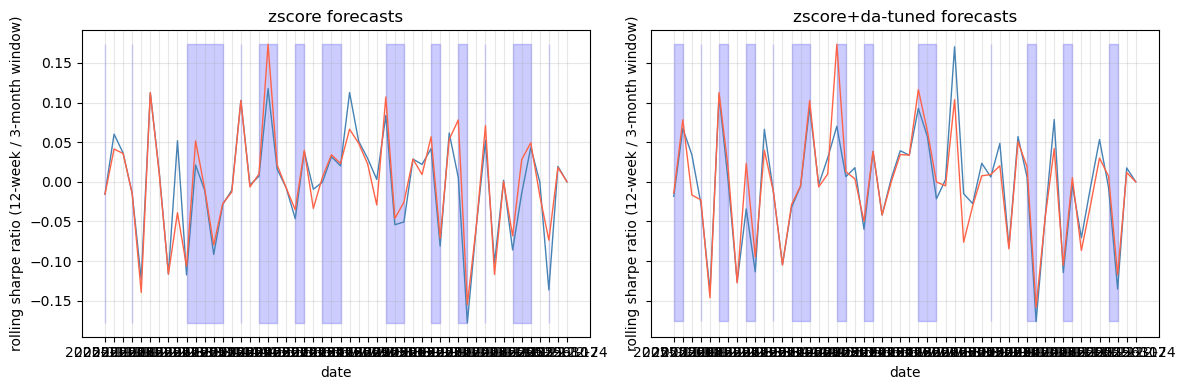

In [24]:
# === plot rolling sharpe
x = old_base_ret.index
y_left_1 = old_base_ret
y_left_2 = old_reg_ret

y_right_1 = base_ret
y_right_2 = reg_ret

left_title = "zscore forecasts"
right_title = "zscore+da-tuned forecasts"
x_label = "date"
y_label = "rolling sharpe ratio (12-week / 3-month window)"

label_1 = "baseline"
label_2 = "regime"

# --- side-by-side plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# Left plot
axes[0].plot(x, y_left_1, color="steelblue", linewidth=1, label=label_1)
axes[0].plot(x, y_left_2, color="tomato", linewidth=1, label=label_2)
axes[0].fill_between(
    x,
    np.min([y_left_1.min(), y_left_2.min()]),   # lower bound
    np.max([y_left_1.max(), y_left_2.max()]),   # upper bound
    where=(y_left_2 > y_left_1),  # shade where regime outperforms baseline
    color="blue",
    alpha=0.2,
    label="Regime outperforms Baseline"
    )
axes[0].set_title(left_title)
axes[0].set_xlabel(x_label)
axes[0].set_ylabel(y_label)

axes[0].grid(True, alpha=0.3)

# Right plot
axes[1].plot(x, y_right_1, color="steelblue", linewidth=1, label=label_1)
axes[1].plot(x, y_right_2, color="tomato", linewidth=1, label=label_2)
axes[1].fill_between(
    x,
    np.min([y_right_1.min(), y_right_2.min()]),   # lower bound
    np.max([y_right_1.max(), y_right_2.max()]),   #
    where=(y_right_2 > y_right_1),  # shade where regime outperforms baseline
    color="blue",
    alpha=0.2,
    label="Regime outperforms Baseline"
    )
axes[1].set_title(right_title)
axes[1].set_xlabel(x_label)
axes[1].set_ylabel(y_label)
axes[1].grid(True, alpha=0.3)

# plt.legend(loc="upper right", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()